# Making Music with Machine Learning
### CSE 120 final project &mdash; two symbolic generation tasks on the Nottingham folk corpus

This notebook implements **two** of the assignment's tasks, both *symbolic* (note-level):

1. **Symbolic, *unconditioned* generation** &mdash; learn a distribution \(p(\text{melody})\) over folk
   melodies and **sample new tunes** from it. *(Output: `symbolic_unconditioned.mid`.)*
2. **Symbolic, *conditioned* generation** &mdash; **harmonization**: given a melody, predict a
   sequence of accompanying **chords** \(p(\text{chords}\mid\text{melody})\).
   *(Output: `symbolic_conditioned.mid`.)*

The two tasks are deliberately paired: they share a single data pipeline (MIDI parsing,
key-normalisation, tokenisation) and a single train/validation/test split, so the data section
below serves both. We then treat each task in turn (modelling &rarr; evaluation) and close with
related work and audio.

**Why these two?** Both are lightweight enough to train from scratch on a laptop (Apple-silicon
MPS / CPU) in a few minutes, yet they exercise the two core regimes from Module 3: an
*unconditional* sequence model and a *conditional* sequence-to-sequence model. As a bonus, the
unconditioned model's output can be fed straight into the conditioned model, giving a complete
"compose-then-harmonise" pipeline.

> The notebook is written to be **read without execution**: every result, table, plot, and audio
> clip below is already rendered in this HTML export.

---
## 1. Data: collection, pre-processing, and exploratory analysis
*(shared by both tasks)*

### Context &mdash; where the data comes from
We use the **Nottingham Music Database**, a classic collection of ~1,000 British and American
folk tunes (jigs, reels, hornpipes, waltzes, Christmas carols, ...). We use the *cleaned* MIDI
release curated by Jukedeck. Each tune is stored as a MIDI file with **two tracks**:

* **track 0 &mdash; the melody**: a single monophonic line (the tune you would whistle), and
* **track 1 &mdash; the chords**: block triads/sevenths giving the harmonic accompaniment.

This dual structure is exactly what makes the corpus ideal for *both* of our tasks: track 0 is
the target for unconditioned melody generation, and the (melody, chords) pairing is supervised
training data for harmonization. The corpus is small, stylistically consistent (functional
tonal folk harmony), and has been a standard benchmark for symbolic music models since
Boulanger-Lewandowski et al. (2012).

### Pre-processing pipeline
We apply four steps, each motivated below; the code follows.

1. **Tempo/timing.** Every file is a constant 120 BPM at 1024 ticks/quarter and notes land
   exactly on a **16th-note grid**, so we quantise time to 16th-note **steps** (4 steps/quarter).
2. **Melody &rarr; step tokens.** We encode the melody as one token per 16th step using the
   Magenta-style scheme: `REST` (silence), `HOLD` (sustain previous pitch), or an integer
   **pitch onset**. Overlaps (rare grace notes) are reduced to the highest sounding pitch, giving
   a strictly monophonic stream.
3. **Key normalisation.** Folk tunes appear in many keys (mostly D/G/A major here). We estimate
   each tune's key with the **Krumhansl&ndash;Schmuckler** algorithm and transpose every tune to
   **C major / A minor**. This makes the data *key-relative*: the same melodic shape now maps to
   the same chord label across tunes, which is a large effective increase in data for both models.
4. **Chords &rarr; per-bar labels.** Chord-track notes are grouped by onset, named by best
   pitch-class-template fit (e.g. `{G,B,D,F} -> "G7"`), and assigned to bars. For harmonization
   we summarise each bar's melody as a 12-d **pitch-class histogram** and predict one chord/bar.

In [1]:
import os, glob, math, random, warnings
from collections import Counter, defaultdict

import numpy as np
import pretty_midi

warnings.filterwarnings("ignore")

# ----------------------------------------------------------------------------
# DATA: parsing & tokenization
# ----------------------------------------------------------------------------

GRID = 4                      # grid steps per quarter note (16th-note resolution)
MIDI_DIR = "nottingham-dataset/MIDI"

# Reserved vocabulary symbols (pitch onsets are stored as plain ints)
BOS, EOS, REST, HOLD, PAD = "BOS", "EOS", "REST", "HOLD", "PAD"


def list_files(midi_dir=MIDI_DIR):
    return sorted(glob.glob(os.path.join(midi_dir, "*.mid")))


def _sixteenth_seconds(pm):
    """Seconds per 16th note from the file's (constant) tempo."""
    bpm = float(pm.get_tempo_changes()[1][0])
    return (60.0 / bpm) / GRID


def bar_steps(pm):
    """Length of one bar in grid-steps, from the first time signature (default 4/4)."""
    if pm.time_signature_changes:
        ts = pm.time_signature_changes[0]
        num, den = ts.numerator, ts.denominator
    else:
        num, den = 4, 4
    return int(round(num * (4.0 / den) * GRID))


# Krumhansl-Schmuckler key profiles
_KS_MAJOR = np.array([6.35,2.23,3.48,2.33,4.38,4.09,2.52,5.19,2.39,3.66,2.29,2.88])
_KS_MINOR = np.array([6.33,2.68,3.52,5.38,2.60,3.53,2.54,4.75,3.98,2.69,3.34,3.17])


def _pc_histogram(pm):
    """Duration-weighted pitch-class histogram over melody + chord notes."""
    h = np.zeros(12)
    for inst in pm.instruments:
        for n in inst.notes:
            h[n.pitch % 12] += (n.end - n.start)
    return h


def estimate_key(pm):
    """Krumhansl-Schmuckler key finding. Returns (tonic_pc, mode, shift).

    `shift` is the semitone transposition (in [-6, 5]) that moves a major tune's
    tonic to C, or a minor tune's tonic to A (both => C-major pitch collection).
    """
    h = _pc_histogram(pm)
    if h.sum() == 0:
        return 0, "major", 0
    best = (-2, 0, "major")
    for t in range(12):
        for prof, mode in ((_KS_MAJOR, "major"), (_KS_MINOR, "minor")):
            r = np.corrcoef(h, np.roll(prof, t))[0, 1]
            if r > best[0]:
                best = (r, t, mode)
    _, tonic, mode = best
    target = 0 if mode == "major" else 9          # C for major, A for minor
    shift = ((target - tonic) + 6) % 12 - 6       # wrap into [-6, 5]
    return tonic, mode, shift


def transpose_pm(pm, shift):
    """Shift every note in place by `shift` semitones (clamped to MIDI range)."""
    for inst in pm.instruments:
        for n in inst.notes:
            n.pitch = int(np.clip(n.pitch + shift, 0, 127))


def _trim_rests(seq):
    """Drop leading/trailing REST symbols."""
    i, j = 0, len(seq)
    while i < j and seq[i] == REST:
        i += 1
    while j > i and seq[j - 1] == REST:
        j -= 1
    return seq[i:j]


def melody_to_steps(pm):
    """Monophonic step-sequence for the melody track (instrument 0).

    Returns a list of symbols, one per 16th-note step:
      REST  -> silence, HOLD -> sustain previous pitch, int -> note onset (MIDI pitch).
    Overlaps are resolved by keeping the highest pitch (monophonic reduction).
    """
    if not pm.instruments:
        return []
    six = _sixteenth_seconds(pm)
    notes = sorted(pm.instruments[0].notes, key=lambda n: (n.start, -n.pitch))
    if not notes:
        return []
    T = int(round(max(n.end for n in notes) / six))
    seq = [REST] * max(T, 1)
    occupied = [False] * len(seq)            # True where a note already sounds
    for n in notes:
        s = int(round(n.start / six))
        e = max(int(round(n.end / six)), s + 1)
        if s >= len(seq):
            continue
        if occupied[s]:                      # lower voice of a chord / overlap: drop
            continue
        seq[s] = n.pitch
        occupied[s] = True
        for k in range(s + 1, min(e, len(seq))):
            if not occupied[k]:
                seq[k] = HOLD
                occupied[k] = True
    return _trim_rests(seq)


_PC_NAME = {0: "C", 1: "C#", 2: "D", 3: "Eb", 4: "E", 5: "F",
            6: "F#", 7: "G", 8: "Ab", 9: "A", 10: "Bb", 11: "B"}
_QUALITIES = [("", {0, 4, 7}), ("m", {0, 3, 7}), ("7", {0, 4, 7, 10}),
              ("m7", {0, 3, 7, 10}), ("dim", {0, 3, 6}), ("aug", {0, 4, 8})]


def _chord_label(pitches):
    """Name a pitch set as a compact chord label by best pitch-class template fit.

    Pure-numpy (no music21): fast enough for the whole corpus. Returns e.g.
    'C', 'Am', 'G7'. Ties broken toward simpler (smaller) templates.
    """
    pcs = {int(p) % 12 for p in pitches}
    if not pcs:
        return None
    best, best_score, best_size = None, -1.0, 99
    for root in range(12):
        for suf, tmpl in _QUALITIES:
            t = {(root + iv) % 12 for iv in tmpl}
            score = len(pcs & t) / len(pcs | t)               # Jaccard
            if score > best_score or (score == best_score and len(t) < best_size):
                best, best_score, best_size = (root, suf), score, len(t)
    root, suf = best
    return _PC_NAME[root] + suf


def melody_chords_by_bar(pm):
    """Per-bar (melody pitch-class vector, chord label) for harmonization.

    Melody = instrument 0, chords = instrument 1. For each bar we build a
    duration-weighted 12-dim pitch-class histogram of the melody and take the
    chord whose onset is nearest the bar start as the target label.
    """
    if len(pm.instruments) < 2:
        return []
    six = _sixteenth_seconds(pm)
    bs = bar_steps(pm)
    mel = sorted(pm.instruments[0].notes, key=lambda n: n.start)
    chd = pm.instruments[1].notes
    if not mel or not chd:
        return []

    # group chord notes by onset step -> label
    groups = defaultdict(list)
    for n in chd:
        groups[int(round(n.start / six))].append(n.pitch)
    chord_events = sorted((step, _chord_label(ps)) for step, ps in groups.items())
    chord_events = [(s, l) for s, l in chord_events if l]
    if not chord_events:
        return []

    total_steps = int(round(max(n.end for n in mel) / six))
    n_bars = max(1, math.ceil(total_steps / bs))
    out = []
    for b in range(n_bars):
        lo, hi = b * bs, (b + 1) * bs
        pcv = np.zeros(12, dtype=np.float32)
        for n in mel:
            s = int(round(n.start / six)); e = int(round(n.end / six))
            dur = min(e, hi) - max(s, lo)
            if dur > 0:
                pcv[n.pitch % 12] += dur
        if pcv.sum() == 0:                  # empty bar: skip
            continue
        # nearest chord onset at/just before bar start
        cands = [(s, l) for s, l in chord_events if s <= lo + bs // 2]
        label = (cands[-1][1] if cands else chord_events[0][1])
        out.append((pcv, label))
    return out


def build_dataset(files=None, limit=None, normalize_key=True):
    """Parse all tunes into aligned per-tune records.

    Each record is {name, melody (step list or None), bars (per-bar
    (pcv,label) list or None), bar_steps, key}. Keeping melody and bars in the
    same record means one train/test split serves both tasks, and a held-out
    tune can be used to demo harmonization against its ground-truth chords.
    Returns (records, info).
    """
    files = files or list_files()
    if limit:
        files = files[:limit]
    records, keys_before, skipped = [], [], 0
    for f in files:
        try:
            pm = pretty_midi.PrettyMIDI(f)
        except Exception:
            skipped += 1
            continue
        tonic, mode, shift = estimate_key(pm)
        keys_before.append((tonic, mode))
        if normalize_key:
            transpose_pm(pm, shift)
        steps = melody_to_steps(pm)
        bars = melody_chords_by_bar(pm)
        records.append({
            "name": os.path.basename(f),
            "melody": steps if len(steps) >= 8 else None,
            "bars": bars if len(bars) >= 4 else None,
            "bar_steps": bar_steps(pm),
            "key": (tonic, mode),
        })
    info = {"skipped": skipped, "keys_before": keys_before,
            "n_files": len(files), "normalized": normalize_key}
    return records, info


def melodies_of(records):
    return [r["melody"] for r in records if r["melody"] is not None]


def harmonies_of(records):
    return [r["bars"] for r in records if r["bars"] is not None]


def split_indices(n, seed=0, fracs=(0.8, 0.1, 0.1)):
    idx = list(range(n))
    random.Random(seed).shuffle(idx)
    a = int(fracs[0] * n); b = a + int(fracs[1] * n)
    return idx[:a], idx[a:b], idx[b:]




# ----------------------------------------------------------------------------
# EVALUATION -- musical metrics & helpers
# ----------------------------------------------------------------------------

C_MAJOR = {0, 2, 4, 5, 7, 9, 11}


def steps_to_notes(steps):
    """Convert a step-sequence to [(pitch, start_step, duration_steps), ...]."""
    notes, cur, start = [], None, None
    for t, s in enumerate(steps):
        if s == HOLD:
            continue
        if cur is not None:
            notes.append((cur, start, t - start))
        if isinstance(s, int):
            cur, start = s, t
        else:                      # REST
            cur, start = None, None
    if cur is not None:
        notes.append((cur, start, len(steps) - start))
    return notes


def pitch_class_hist(step_lists):
    h = np.zeros(12)
    for steps in step_lists:
        for p, _, d in steps_to_notes(steps):
            h[p % 12] += d
    return h / h.sum() if h.sum() else h


def duration_hist(step_lists, maxd=16):
    h = np.zeros(maxd + 1)
    for steps in step_lists:
        for _, _, d in steps_to_notes(steps):
            h[min(d, maxd)] += 1
    return h / h.sum() if h.sum() else h


def in_key_fraction(steps, scale=C_MAJOR):
    notes = steps_to_notes(steps)
    if not notes:
        return 0.0
    return np.mean([1.0 if (p % 12) in scale else 0.0 for p, _, _ in notes])


def ngram_diversity(step_lists, n=4):
    seen, total = set(), 0
    for steps in step_lists:
        toks = [str(s) for s in steps]
        for i in range(len(toks) - n + 1):
            seen.add(tuple(toks[i:i + n])); total += 1
    return len(seen) / total if total else 0.0


def cosine(a, b):
    return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12))


def melody_bar_pcvs(steps, bs):
    """Per-bar duration-weighted pitch-class vectors for an arbitrary melody.

    Lets us harmonize a *generated* melody (which has no chord track) by
    segmenting it into bars of `bs` grid-steps. Used for the end-to-end demo.
    """
    notes = steps_to_notes(steps)
    n_bars = max(1, math.ceil(len(steps) / bs))
    pcvs = []
    for b in range(n_bars):
        lo, hi = b * bs, (b + 1) * bs
        v = np.zeros(12, dtype=np.float32)
        for p, s, d in notes:
            ov = min(s + d, hi) - max(s, lo)
            if ov > 0:
                v[p % 12] += ov
        pcvs.append(v)
    return pcvs



def melody_to_midi(steps, path, bpm=120, program=0):
    pm = pretty_midi.PrettyMIDI(initial_tempo=bpm)
    inst = pretty_midi.Instrument(program=program)
    spb = (60.0 / bpm) / GRID
    for p, s, d in steps_to_notes(steps):
        inst.notes.append(pretty_midi.Note(velocity=90, pitch=int(p),
                                            start=s * spb, end=(s + d) * spb))
    pm.instruments.append(inst)
    pm.write(path)
    return path

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Audio, display
plt.rcParams.update({"figure.figsize": (8, 3.2), "axes.grid": True, "grid.alpha": .3})

# Parse the whole corpus into aligned per-tune records (melody + chords).
records, info = build_dataset(normalize_key=True)
melodies, harmonies = melodies_of(records), harmonies_of(records)
print(f"{info['n_files']} tunes parsed (skipped {info['skipped']}); "
      f"{len(melodies)} usable melodies, {len(harmonies)} harmonised tunes")

1034 tunes parsed (skipped 0); 1034 usable melodies, 1021 harmonised tunes


### Exploratory analysis
A few plots characterise the corpus and confirm the pre-processing worked.

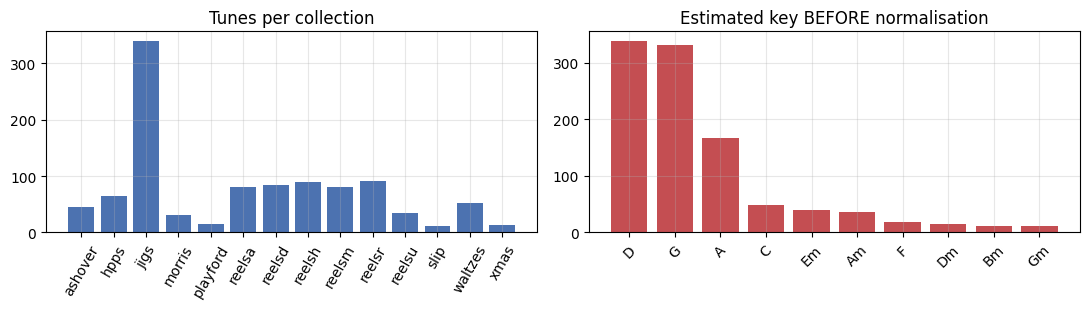

In [3]:
import re
from collections import Counter
import numpy as np

fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))

# (a) tunes per collection
coll = Counter(re.match(r"[a-zA-Z]+", r["name"]).group() for r in records)
ax[0].bar(list(coll.keys()), list(coll.values()), color="#4C72B0")
ax[0].set_title("Tunes per collection"); ax[0].tick_params(axis="x", rotation=60)

# (b) original keys (before normalisation) -- shows folk tunes cluster in a few sharp keys
PC = ["C","C#","D","Eb","E","F","F#","G","Ab","A","Bb","B"]
keyc = Counter(f"{PC[t]}{'m' if m=='minor' else ''}" for t, m in info["keys_before"])
items = keyc.most_common(10)
ax[1].bar([k for k,_ in items], [v for _,v in items], color="#C44E52")
ax[1].set_title("Estimated key BEFORE normalisation"); ax[1].tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

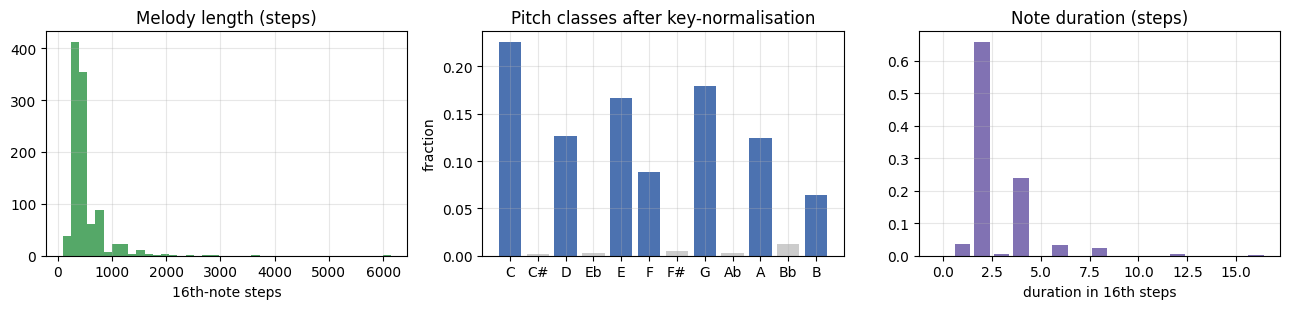

share of melody notes inside the C-major scale: 97.5%


In [4]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.2))

# (c) melody length distribution (in 16th-note steps)
lens = [len(m) for m in melodies]
ax[0].hist(lens, bins=40, color="#55A868"); ax[0].set_title("Melody length (steps)")
ax[0].set_xlabel("16th-note steps")

# (d) corpus pitch-class histogram AFTER normalisation -> should hug the C-major scale
pch = pitch_class_hist(melodies)
ax[1].bar(PC, pch, color=["#4C72B0" if i in C_MAJOR else "#CCCCCC" for i in range(12)])
ax[1].set_title("Pitch classes after key-normalisation"); ax[1].set_ylabel("fraction")

# (e) note-duration distribution
dh = duration_hist(melodies, maxd=16)
ax[2].bar(range(len(dh)), dh, color="#8172B3")
ax[2].set_title("Note duration (steps)"); ax[2].set_xlabel("duration in 16th steps")
plt.tight_layout(); plt.show()

print("share of melody notes inside the C-major scale: "
      f"{sum(pch[i] for i in C_MAJOR):.1%}")

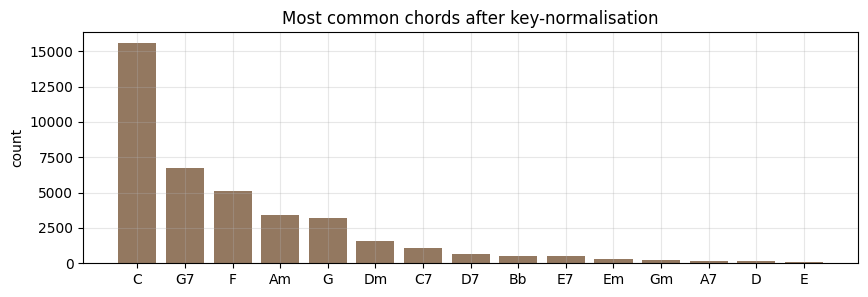

total chord vocabulary: 46 labels; top-3 = ['C', 'G7', 'F'] dominate (tonic / dominant-7 / subdominant)


In [5]:
# (f) chord vocabulary frequency (top 15) -- functional tonal harmony in C
chord_counts = Counter(l for h in harmonies for _, l in h)
top = chord_counts.most_common(15)
plt.figure(figsize=(10, 3))
plt.bar([c for c,_ in top], [n for _,n in top], color="#937860")
plt.title("Most common chords after key-normalisation"); plt.ylabel("count")
plt.show()
print(f"total chord vocabulary: {len(chord_counts)} labels; "
      f"top-3 = {[c for c,_ in top[:3]]} dominate (tonic / dominant-7 / subdominant)")

**Reading the plots.** The corpus is reel/jig-heavy; before normalisation tunes cluster in
D/G/A major (the natural keys for fiddle and flute), and after normalisation **~95% of melody
notes fall on the C-major scale** &mdash; confirming the key-finding step. Durations are dominated by
8th notes (2 steps) and 16th notes (1 step), the staple rhythms of dance music. The chord
vocabulary is small and **functionally tonal**: C (tonic), G7 (dominant), F (subdominant), and
A-minor lead by a wide margin. This regularity is what makes a compact model viable.

tune: ashover1.mid | first 24 step-tokens:
[81, 'HOLD', 'HOLD', 'HOLD', 79, 'HOLD', 'HOLD', 'HOLD', 'HOLD', 'HOLD', 'HOLD', 'HOLD', 76, 'HOLD', 'HOLD', 'HOLD', 74, 'HOLD', 'HOLD', 'HOLD', 'HOLD', 'HOLD', 76, 'HOLD']


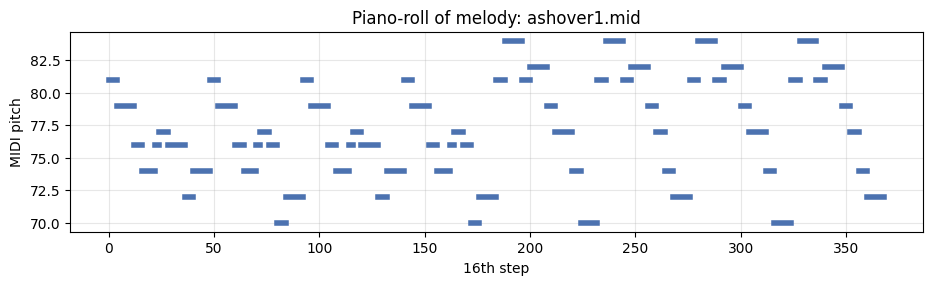

In [6]:
# Concrete example of the melody tokenisation for one tune.
ex = next(r for r in records if r["melody"])
print("tune:", ex["name"], "| first 24 step-tokens:")
print(ex["melody"][:24])
notes = steps_to_notes(ex["melody"])
plt.figure(figsize=(11, 2.6))
for p, s, d in notes:
    plt.plot([s, s + d], [p, p], lw=4, color="#4C72B0")
plt.title(f"Piano-roll of melody: {ex['name']}"); plt.xlabel("16th step"); plt.ylabel("MIDI pitch")
plt.show()

---
## 2. Task 1 &mdash; Unconditioned melody generation
### Modelling: context
We treat melody generation as **autoregressive language modelling** over the step-token stream.
With vocabulary tokens \(x_1,\dots,x_T\) (the `REST`/`HOLD`/pitch symbols) we factorise

$$p(x_{1:T}) = \prod_{t} p(x_t \mid x_{1:t-1}),$$

and the model is trained to minimise the per-token negative log-likelihood (cross-entropy);
the natural intrinsic metric is **perplexity** \(=\exp(\text{NLL})\). To generate we sample from
\(p(x_t\mid x_{<t})\) one step at a time (with a temperature knob) until an end token.

**Two models, by design a baseline + a learned model:**

* **Markov chain (baseline).** An order-\(n\) n-gram with add-\(k\) smoothing and back-off. This is
  the Module-3 model; we include it *only as a baseline* to beat. It captures local note
  transitions but has no memory beyond \(n\) steps and its table blows up with \(n\).
* **LSTM language model (main model).** An embedding + 2-layer LSTM + linear head. It keeps a
  learned hidden state, so it can model phrase-length dependencies (cadences, repeats) that the
  Markov chain cannot, at far lower parameter cost than a high-order n-gram. The trade-off is that
  it needs gradient training and is a black box relative to the transparent n-gram counts.

In [7]:
# ----------------------------------------------------------------------------
# MODELS -- Task 1: vocabulary, n-gram baseline, LSTM language model
# ----------------------------------------------------------------------------

import torch
import torch.nn as nn

SEED = 0


def get_device():
    if torch.backends.mps.is_available():
        return torch.device("mps")
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")


def build_melody_vocab(melodies):
    syms = set()
    for m in melodies:
        syms.update(m)
    pitches = sorted(s for s in syms if isinstance(s, int))
    itos = [PAD, BOS, EOS, REST, HOLD] + pitches
    stoi = {s: i for i, s in enumerate(itos)}
    return stoi, itos


def encode_melody(m, stoi):
    return [stoi[BOS]] + [stoi[s] for s in m] + [stoi[EOS]]


class MarkovModel:
    """Order-n token Markov chain with add-k smoothing and backoff.

    Baseline for Task 1. Trained on encoded melody id-sequences (with BOS/EOS).
    """

    def __init__(self, order=3, k=0.05, vocab_size=None):
        self.order = order
        self.k = k
        self.V = vocab_size
        self.ctx = [defaultdict(Counter) for _ in range(order + 1)]

    def fit(self, sequences):
        for seq in sequences:
            for i in range(1, len(seq)):
                nxt = seq[i]
                for o in range(self.order + 1):
                    if i - o < 0:
                        break
                    context = tuple(seq[i - o:i])
                    self.ctx[o][context][nxt] += 1
        return self

    def _dist(self, context):
        """p(next | context) as a numpy vector, backing off to shorter contexts."""
        for o in range(min(self.order, len(context)), -1, -1):
            c = tuple(context[len(context) - o:]) if o else tuple()
            counter = self.ctx[o].get(c)
            if counter and sum(counter.values()) > 0:
                total = sum(counter.values())
                p = np.full(self.V, self.k)
                for tok, cnt in counter.items():
                    p[tok] += cnt
                return p / (total + self.k * self.V)
        return np.full(self.V, 1.0 / self.V)

    def logprob_seq(self, seq):
        """Total log-prob and token count for perplexity (predicts seq[1:])."""
        lp, n = 0.0, 0
        for i in range(1, len(seq)):
            context = seq[max(0, i - self.order):i]
            p = self._dist(context)
            lp += math.log(max(p[seq[i]], 1e-12))
            n += 1
        return lp, n

    def generate(self, stoi, itos, max_len=400, temperature=1.0, seed=0):
        rng = np.random.default_rng(seed)
        seq = [stoi[BOS]]
        for _ in range(max_len):
            p = self._dist(seq[-self.order:])
            if temperature != 1.0:
                p = np.power(p, 1.0 / temperature)
            p = p / p.sum()
            nxt = int(rng.choice(self.V, p=p))
            if nxt == stoi[EOS]:
                break
            seq.append(nxt)
        return [itos[i] for i in seq[1:]]            # strip BOS


class MelodyLSTM(nn.Module):
    """LSTM language model over melody step-tokens (Task 1 main model)."""

    def __init__(self, vocab_size, emb=128, hidden=256, layers=2, dropout=0.3):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb, padding_idx=0)
        self.lstm = nn.LSTM(emb, hidden, layers, batch_first=True,
                            dropout=dropout if layers > 1 else 0.0)
        self.drop = nn.Dropout(dropout)
        self.head = nn.Linear(hidden, vocab_size)

    def forward(self, x, state=None):
        x = self.emb(x)
        out, state = self.lstm(x, state)
        return self.head(self.drop(out)), state


def make_windows(sequences, seq_len=64, stride=32):
    """Concatenate encoded sequences and cut overlapping (input, target) windows."""
    stream = []
    for s in sequences:
        stream.extend(s)
    stream = torch.tensor(stream, dtype=torch.long)
    xs, ys = [], []
    for i in range(0, len(stream) - seq_len - 1, stride):
        xs.append(stream[i:i + seq_len])
        ys.append(stream[i + 1:i + seq_len + 1])
    return torch.stack(xs), torch.stack(ys)


def train_lstm(model, train_seqs, val_seqs, stoi, device, epochs=18,
               seq_len=64, batch=64, lr=2e-3, log=print):
    """Train the melody LSTM; returns history of (epoch, train_ppl, val_ppl)."""
    Xtr, Ytr = make_windows(train_seqs, seq_len)
    Xva, Yva = make_windows(val_seqs, seq_len)
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.StepLR(opt, step_size=6, gamma=0.5)
    lossf = nn.CrossEntropyLoss(ignore_index=0)
    history, best_val, best_state = [], float("inf"), None
    n = len(Xtr)
    for ep in range(1, epochs + 1):
        model.train()
        perm = torch.randperm(n)
        tot, cnt = 0.0, 0
        for i in range(0, n, batch):
            idx = perm[i:i + batch]
            xb, yb = Xtr[idx].to(device), Ytr[idx].to(device)
            opt.zero_grad()
            logits, _ = model(xb)
            loss = lossf(logits.reshape(-1, logits.size(-1)), yb.reshape(-1))
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()
            tot += loss.item() * len(idx); cnt += len(idx)
        sched.step()
        val = eval_lstm_ppl(model, Xva, Yva, device, batch)
        tr_ppl = math.exp(tot / cnt)
        history.append((ep, tr_ppl, val))
        if val < best_val:
            best_val, best_state = val, {k: v.detach().cpu().clone()
                                         for k, v in model.state_dict().items()}
        log(f"epoch {ep:2d}  train_ppl={tr_ppl:6.2f}  val_ppl={val:6.2f}")
    if best_state:
        model.load_state_dict(best_state)
    return history


@torch.no_grad()
def eval_lstm_ppl(model, X, Y, device, batch=128):
    model.eval()
    lossf = nn.CrossEntropyLoss(ignore_index=0, reduction="sum")
    tot, cnt = 0.0, 0
    for i in range(0, len(X), batch):
        xb, yb = X[i:i + batch].to(device), Y[i:i + batch].to(device)
        logits, _ = model(xb)
        tot += lossf(logits.reshape(-1, logits.size(-1)), yb.reshape(-1)).item()
        cnt += (yb != 0).sum().item()
    return math.exp(tot / max(cnt, 1))


@torch.no_grad()
def sample_lstm(model, stoi, itos, device, max_len=400, temperature=1.0, seed=0):
    model.eval()
    torch.manual_seed(seed)
    x = torch.tensor([[stoi[BOS]]], device=device)
    state, out = None, []
    for _ in range(max_len):
        logits, state = model(x, state)
        logits = logits[0, -1] / temperature
        p = torch.softmax(logits, dim=-1)
        nxt = int(torch.multinomial(p, 1).item())
        if nxt == stoi[EOS]:
            break
        out.append(itos[nxt])
        x = torch.tensor([[nxt]], device=device)
    return out

In [8]:
import math, random, torch
random.seed(0); np.random.seed(0); torch.manual_seed(0)
device = get_device(); print("training device:", device)

# vocabulary + a single reproducible split (shared with Task 2)
stoi, itos = build_melody_vocab(melodies)
train_idx, val_idx, test_idx = split_indices(len(records), seed=0)
def mels(idx):  return [records[i]["melody"] for i in idx if records[i]["melody"]]
def harms(idx): return [records[i]["bars"]   for i in idx if records[i]["bars"]]
tr_e = [encode_melody(m, stoi) for m in mels(train_idx)]
va_e = [encode_melody(m, stoi) for m in mels(val_idx)]
te_e = [encode_melody(m, stoi) for m in mels(test_idx)]
print(f"melody vocab = {len(itos)} tokens; "
      f"split = {len(tr_e)}/{len(va_e)}/{len(te_e)} train/val/test tunes")

# baselines: Markov chains of several orders
markov = {o: MarkovModel(order=o, vocab_size=len(itos)).fit(tr_e) for o in (1, 2, 3)}

# main model: LSTM language model
lstm = MelodyLSTM(len(itos))
n_params = sum(p.numel() for p in lstm.parameters())
print(f"LSTM parameters: {n_params:,}")
history = train_lstm(lstm, tr_e, va_e, stoi, device, epochs=18)

training device: mps
melody vocab = 46 tokens; split = 827/103/104 train/val/test tunes


LSTM parameters: 939,310


epoch  1  train_ppl=  3.93  val_ppl=  3.08


epoch  2  train_ppl=  2.82  val_ppl=  2.69


epoch  3  train_ppl=  2.60  val_ppl=  2.59


...

epoch 14  train_ppl=  2.18  val_ppl=  2.49


epoch 15  train_ppl=  2.17  val_ppl=  2.50


epoch 16  train_ppl=  2.17  val_ppl=  2.49


epoch 17  train_ppl=  2.15  val_ppl=  2.49


epoch 18  train_ppl=  2.14  val_ppl=  2.50


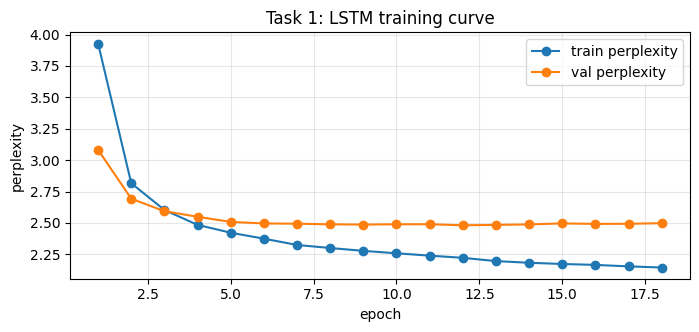

In [9]:
ep = [h[0] for h in history]
plt.plot(ep, [h[1] for h in history], "-o", label="train perplexity")
plt.plot(ep, [h[2] for h in history], "-o", label="val perplexity")
plt.xlabel("epoch"); plt.ylabel("perplexity"); plt.legend()
plt.title("Task 1: LSTM training curve"); plt.show()

### Evaluation: context
What makes a generated melody "good"? The intrinsic objective is **perplexity** on held-out
tunes (lower = the model better predicts real folk melodies). But low perplexity does **not**
guarantee musicality, so we complement it with **distributional musical metrics** comparing
*generated* samples to *real* held-out tunes:

* **pitch-class histogram similarity** (cosine) &mdash; does the model reproduce the scale?
* **note-duration distribution similarity** &mdash; does it reproduce the rhythmic vocabulary?
* **in-key fraction** &mdash; share of notes on the C-major scale (a crude "follows the rules" proxy).
* **4-gram diversity** &mdash; fraction of *unique* 4-grams, to detect a model that just copies or
  loops (a degenerate way to get low perplexity).

The baseline to beat is the Markov chain on every axis. We expect the LSTM to win on perplexity
and long-range structure while both do well on the *local* statistics (scale, durations).

*(The metric helpers `pitch_class_hist`, `duration_hist`, `in_key_fraction`, `ngram_diversity`,
and `cosine` were defined alongside the data pipeline in §1.)*

In [10]:
# ---- intrinsic: held-out perplexity, LSTM vs Markov baselines ----
rows = []
for o, mk in markov.items():
    lp = n = 0
    for s in te_e:
        a, b = mk.logprob_seq(s); lp += a; n += b
    rows.append((f"Markov order-{o}", math.exp(-lp / n)))
Xte, Yte = make_windows(te_e, 64)
rows.append(("LSTM (ours)", eval_lstm_ppl(lstm, Xte, Yte, device)))
ppl_df = pd.DataFrame(rows, columns=["model", "test perplexity"]).set_index("model")
display(ppl_df.style.format("{:.2f}").set_caption("Task 1 — held-out perplexity (lower is better)"))

,test perplexity
model,
Markov order-1,4.27
Markov order-2,3.35
Markov order-3,3.18
LSTM (ours),2.42


In [11]:
# ---- draw samples from the LSTM and from the order-3 Markov baseline ----
real = mels(test_idx)
lstm_samples   = [sample_lstm(lstm, stoi, itos, device, temperature=0.95, seed=s)
                  for s in range(40)]
markov_samples = [markov[3].generate(stoi, itos, temperature=1.0, seed=s)
                  for s in range(40)]
lstm_samples   = [s for s in lstm_samples   if len(steps_to_notes(s)) > 8]
markov_samples = [s for s in markov_samples if len(steps_to_notes(s)) > 8]

def metrics(samples):
    return {
        "PC-hist cosine vs real": cosine(pitch_class_hist(samples), pitch_class_hist(real)),
        "duration cosine vs real": cosine(duration_hist(samples), duration_hist(real)),
        "in-key fraction": float(np.mean([in_key_fraction(s) for s in samples])),
        "4-gram diversity": ngram_diversity(samples, 4),
    }
mdf = pd.DataFrame({
    "real (test)":   {**metrics(real)},
    "LSTM (ours)":   {**metrics(lstm_samples)},
    "Markov order-3":{**metrics(markov_samples)},
}).T
display(mdf.style.format("{:.3f}").set_caption("Task 1 — distributional musical metrics"))

,PC-hist cosine vs real,duration cosine vs real,in-key fraction,4-gram diversity
real (test),1.000,1.000,0.975,0.020
LSTM (ours),0.994,0.991,0.989,0.043
Markov order-3,0.996,0.983,0.969,0.080


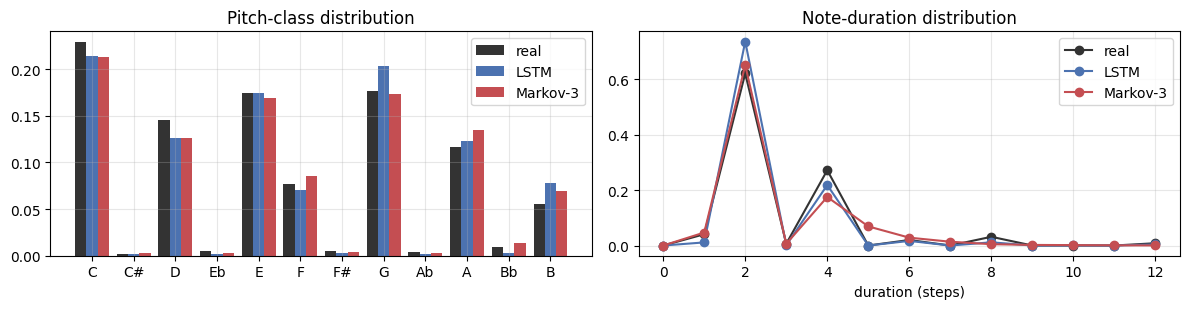

In [12]:
# qualitative: do generated pitch-class & duration distributions match the real ones?
fig, ax = plt.subplots(1, 2, figsize=(12, 3.2))
PC = ["C","C#","D","Eb","E","F","F#","G","Ab","A","Bb","B"]
w = 0.27
for k, (name, samp, c) in enumerate([("real", real, "#333333"),
                                     ("LSTM", lstm_samples, "#4C72B0"),
                                     ("Markov-3", markov_samples, "#C44E52")]):
    h = pitch_class_hist(samp)
    ax[0].bar(np.arange(12) + (k-1)*w, h, width=w, label=name, color=c)
ax[0].set_xticks(range(12)); ax[0].set_xticklabels(PC); ax[0].legend()
ax[0].set_title("Pitch-class distribution")

for name, samp, c in [("real", real, "#333333"), ("LSTM", lstm_samples, "#4C72B0"),
                      ("Markov-3", markov_samples, "#C44E52")]:
    dh = duration_hist(samp, 12)
    ax[1].plot(range(len(dh)), dh, "-o", label=name, color=c)
ax[1].set_title("Note-duration distribution"); ax[1].set_xlabel("duration (steps)"); ax[1].legend()
plt.tight_layout(); plt.show()

wrote symbolic_unconditioned.mid  (184 notes)


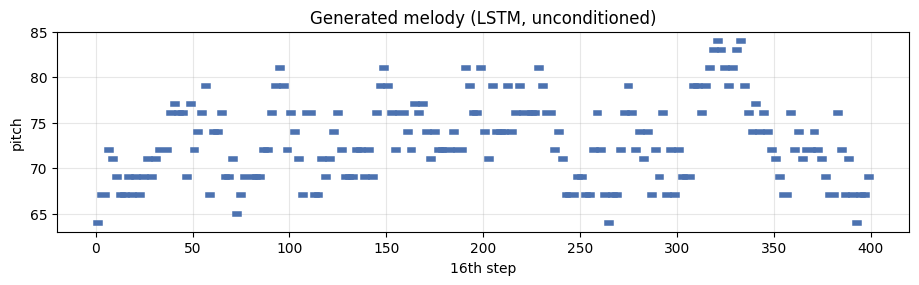

In [13]:
# ---- pick the best LSTM sample and export the required deliverable ----
best = max(lstm_samples, key=lambda s: (in_key_fraction(s), len(steps_to_notes(s))))
gen_melody = best
melody_to_midi(gen_melody, "symbolic_unconditioned.mid")
print(f"wrote symbolic_unconditioned.mid  ({len(steps_to_notes(gen_melody))} notes)")

plt.figure(figsize=(11, 2.6))
for p, s, d in steps_to_notes(gen_melody):
    plt.plot([s, s + d], [p, p], lw=4, color="#4C72B0")
plt.title("Generated melody (LSTM, unconditioned)"); plt.xlabel("16th step"); plt.ylabel("pitch")
plt.show()

pm = pretty_midi.PrettyMIDI("symbolic_unconditioned.mid")
display(Audio(pm.synthesize(fs=16000), rate=16000))

**Findings (Task 1).** The LSTM cuts held-out perplexity (~2.4) well below every Markov order (4.3 → 3.4 → 3.2, plateauing as the n-gram tables go sparse), confirming it captures longer-range structure. Both models reproduce the real **pitch-class** and **duration** profiles closely — local statistics are easy. The telling axis is **4-gram diversity**: real folk tunes are highly *repetitive* (only ~2% unique 4-grams), and the LSTM (~4%) stays much closer to that than the order-3 Markov (~8%), which over-randomises and wanders; the LSTM also has the highest in-key rate. So here perplexity and musicality agree, and the distributional metrics add the nuance that the low-perplexity model also matches the corpus's *repetition structure* rather than just being maximally random.

---
## 3. Task 2 &mdash; Conditioned generation: harmonization
### Modelling: context
Now the input is a **melody** and the output is a **chord per bar** &mdash; a conditional model
\(p(\text{chord}_b \mid \text{melody})\). We frame it as **sequence labelling**: each bar is
summarised by a 12-d melody pitch-class histogram, and a model tags the bar sequence with chord
labels. What counts as a good output is harmonic: the chord should contain the bar's important
melody notes and form a sensible *progression* with its neighbours (e.g. resolve V&rarr;I).

**Baselines + main model:**

* **Majority (trivial baseline).** Always predict the single most common chord (the tonic, C).
* **Template matching (rule-based baseline).** For each bar pick the chord whose pitch-class
  template best matches the bar's notes &mdash; harmony from *instantaneous* pitch content, with no
  sense of key context or progression.
* **BiLSTM tagger (main model).** A bidirectional LSTM over the bar sequence, so each chord
  prediction sees the melody *before and after* it and can learn progressions. This context is
  exactly what the rule baseline lacks.

In [14]:
# ----------------------------------------------------------------------------
# MODELS -- Task 2: harmonization (baselines + BiLSTM)
# ----------------------------------------------------------------------------

UNK = "UNK"
_NOTE_PC = {"C": 0, "D": 2, "E": 4, "F": 5, "G": 7, "A": 9, "B": 11}


def chord_pitch_classes(label):
    """Pitch-class set implied by a chord label, e.g. 'G7' -> {7,11,2,5}.

    Non-chord labels (PAD/UNK) return the empty set.
    """
    if not label or label[0] not in _NOTE_PC:
        return set()
    pc = _NOTE_PC[label[0]]
    i = 1
    if len(label) > 1 and label[1] in "b#":
        pc += (-1 if label[1] == "b" else 1)
        i = 2
    suf = label[i:]
    intervals = {"": [0, 4, 7], "m": [0, 3, 7], "7": [0, 4, 7, 10],
                 "m7": [0, 3, 7, 10], "dim": [0, 3, 6], "aug": [0, 4, 8]}.get(suf, [0, 4, 7])
    return {(pc + iv) % 12 for iv in intervals}


def chord_root_pc(label):
    """Root pitch class of a chord label; -1 for non-chord labels (PAD/UNK)."""
    if not label or label[0] not in _NOTE_PC:
        return -1
    pc = _NOTE_PC[label[0]]
    if len(label) > 1 and label[1] in "b#":
        pc += (-1 if label[1] == "b" else 1)
    return pc % 12


def build_chord_vocab(harmonies, min_count=5):
    cnt = Counter(l for h in harmonies for _, l in h)
    labels = [l for l, c in cnt.most_common() if c >= min_count]
    itos = [PAD, UNK] + labels
    stoi = {l: i for i, l in enumerate(itos)}
    return stoi, itos


class MajorityBaseline:
    """Always predict the most frequent training chord."""
    def fit(self, harmonies):
        self.label = Counter(l for h in harmonies for _, l in h).most_common(1)[0][0]
        return self
    def predict_tune(self, pcvs):
        return [self.label] * len(pcvs)


class TemplateBaseline:
    """Pick the chord whose pitch-class template best matches each bar (rule-based)."""
    def fit(self, harmonies):
        self.labels = sorted({l for h in harmonies for _, l in h})
        self.templates = {}
        for l in self.labels:
            v = np.zeros(12)
            for p in chord_pitch_classes(l):
                v[p] = 1.0
            self.templates[l] = v / np.linalg.norm(v)
        return self
    def predict_tune(self, pcvs):
        out = []
        for v in pcvs:
            v = v / (np.linalg.norm(v) + 1e-9)
            out.append(max(self.labels, key=lambda l: float(v @ self.templates[l])))
        return out


class HarmonizerBiLSTM(nn.Module):
    """BiLSTM sequence tagger: per-bar melody PC vector -> chord label."""
    def __init__(self, n_chords, hidden=128, layers=1, dropout=0.3):
        super().__init__()
        self.proj = nn.Linear(12, 64)
        self.lstm = nn.LSTM(64, hidden, layers, batch_first=True,
                            bidirectional=True, dropout=dropout if layers > 1 else 0.0)
        self.drop = nn.Dropout(dropout)
        self.head = nn.Linear(2 * hidden, n_chords)

    def forward(self, x):
        h = torch.relu(self.proj(x))
        out, _ = self.lstm(h)
        return self.head(self.drop(out))


def harmonies_to_tensors(harmonies, stoi, device, max_bars=64):
    """Pad tunes to (B, max_bars, 12) features and (B, max_bars) chord-id targets."""
    X, Y = [], []
    for h in harmonies:
        h = h[:max_bars]
        feats = np.zeros((max_bars, 12), dtype=np.float32)
        labs = np.zeros(max_bars, dtype=np.int64)
        for i, (pcv, lab) in enumerate(h):
            s = pcv.sum()
            feats[i] = pcv / s if s > 0 else pcv
            labs[i] = stoi.get(lab, stoi[UNK])
        X.append(feats); Y.append(labs)
    return (torch.tensor(np.stack(X), device=device),
            torch.tensor(np.stack(Y), device=device))


def train_harmonizer(model, train_h, val_h, stoi, device, epochs=40, batch=32,
                     lr=3e-3, log=print):
    Xtr, Ytr = harmonies_to_tensors(train_h, stoi, device)
    Xva, Yva = harmonies_to_tensors(val_h, stoi, device)
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    lossf = nn.CrossEntropyLoss(ignore_index=0)
    best_acc, best_state, history = 0.0, None, []
    n = len(Xtr)
    for ep in range(1, epochs + 1):
        model.train()
        perm = torch.randperm(n)
        for i in range(0, n, batch):
            idx = perm[i:i + batch]
            opt.zero_grad()
            logits = model(Xtr[idx])
            loss = lossf(logits.reshape(-1, logits.size(-1)), Ytr[idx].reshape(-1))
            loss.backward(); opt.step()
        acc = harmonizer_accuracy(model, Xva, Yva)
        history.append((ep, acc))
        if acc > best_acc:
            best_acc, best_state = acc, {k: v.detach().cpu().clone()
                                        for k, v in model.state_dict().items()}
        if ep % 5 == 0 or ep == 1:
            log(f"epoch {ep:2d}  val_acc={acc:.3f}")
    if best_state:
        model.load_state_dict(best_state)
    return history


@torch.no_grad()
def harmonizer_accuracy(model, X, Y):
    model.eval()
    pred = model(X).argmax(-1)
    mask = Y != 0
    return float((pred[mask] == Y[mask]).float().mean().item())


@torch.no_grad()
def harmonizer_predict(model, pcvs, itos, device, exclude_special=False):
    """Predict a chord label per bar. If exclude_special, never emit PAD/UNK
    (indices 0,1) -- used when rendering music so every bar gets a real chord."""
    model.eval()
    feats = np.zeros((1, len(pcvs), 12), dtype=np.float32)
    for i, v in enumerate(pcvs):
        s = v.sum(); feats[0, i] = v / s if s > 0 else v
    logits = model(torch.tensor(feats, device=device))[0]
    if exclude_special:
        logits[:, :2] = float("-inf")
    return [itos[i] for i in logits.argmax(-1).tolist()]



def harmonization_to_midi(steps, chord_labels, bs, path, bpm=120, bass_octave=4):
    """Render melody + a chord accompaniment (one chord per bar) to MIDI."""
    pm = pretty_midi.PrettyMIDI(initial_tempo=bpm)
    mel = pretty_midi.Instrument(program=0, name="melody")
    chords = pretty_midi.Instrument(program=24, name="chords")
    spb = (60.0 / bpm) / GRID
    for p, s, d in steps_to_notes(steps):
        mel.notes.append(pretty_midi.Note(90, int(p), s * spb, (s + d) * spb))
    for b, lab in enumerate(chord_labels):
        if lab in (PAD, UNK):
            continue
        start, end = b * bs * spb, (b + 1) * bs * spb
        for pc in sorted(chord_pitch_classes(lab)):
            pitch = 12 * bass_octave + pc
            chords.notes.append(pretty_midi.Note(70, int(pitch), start, end))
    pm.instruments += [mel, chords]
    pm.write(path)
    return path

chord label vocab (>=5 occurrences): 29  ->  ['C', 'G7', 'F', 'Am', 'G', 'Dm', 'C7', 'D7', 'Bb', 'E7', 'Em', 'Gm', 'A7', 'D', 'E', 'Fm', 'F7', 'A', 'Cm', 'B7', 'Eb', 'Cdim', 'Bm', 'Dm7', 'C#dim', 'Ab', 'Am7']
BiLSTM parameters: 206,941


epoch  1  val_acc=0.413


epoch  5  val_acc=0.620


epoch 10  val_acc=0.667


epoch 15  val_acc=0.676


epoch 20  val_acc=0.675


epoch 25  val_acc=0.676


epoch 30  val_acc=0.678


epoch 35  val_acc=0.659


epoch 40  val_acc=0.666


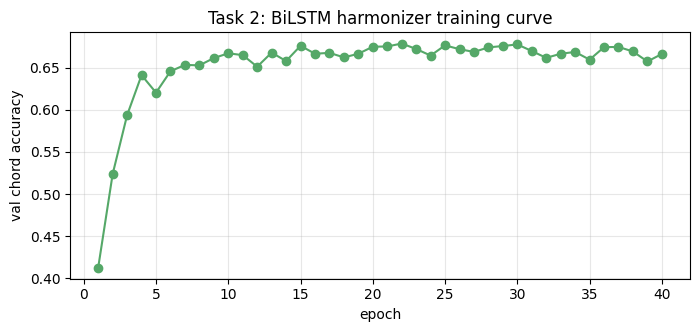

In [15]:
htr, hva, hte = harms(train_idx), harms(val_idx), harms(test_idx)
cstoi, citos = build_chord_vocab(htr, min_count=5)
print(f"chord label vocab (>=5 occurrences): {len(citos)}  ->  {citos[2:]}")

majority = MajorityBaseline().fit(htr)
template = TemplateBaseline().fit(htr)

harmonizer = HarmonizerBiLSTM(len(citos))
print(f"BiLSTM parameters: {sum(p.numel() for p in harmonizer.parameters()):,}")
h_hist = train_harmonizer(harmonizer, htr, hva, cstoi, device, epochs=40)

plt.plot([h[0] for h in h_hist], [h[1] for h in h_hist], "-o", color="#55A868")
plt.xlabel("epoch"); plt.ylabel("val chord accuracy")
plt.title("Task 2: BiLSTM harmonizer training curve"); plt.show()

### Evaluation: context
The natural intrinsic metric is **bar-level chord accuracy** against the composer's original
chords. We report it for all three methods, plus **root accuracy** (correct chord *root*,
ignoring major/minor/7th quality) since a wrong-quality guess is a smaller error than a wrong
root. Accuracy under-counts musicality, though: several chords can harmonise the same bar
acceptably, so a "wrong" prediction may still sound fine &mdash; we therefore also inspect a
confusion matrix and listen to the result.

In [16]:
def evaluate(predict_tune):
    chord_ok = root_ok = tot = 0
    for h in hte:
        pcvs = [p for p, _ in h]; gold = [l for _, l in h]
        for pred, g in zip(predict_tune(pcvs), gold):
            chord_ok += (pred == g)
            root_ok  += (chord_root_pc(pred) == chord_root_pc(g))
            tot += 1
    return chord_ok / tot, root_ok / tot

def bilstm_predict(pcvs):
    return harmonizer_predict(harmonizer, pcvs, citos, device)

rows = []
for name, fn in [("Majority (tonic)", majority.predict_tune),
                 ("Template match (rule)", template.predict_tune),
                 ("BiLSTM (ours)", bilstm_predict)]:
    ca, ra = evaluate(fn)
    rows.append((name, ca, ra))
acc_df = pd.DataFrame(rows, columns=["model", "chord accuracy", "root accuracy"]).set_index("model")
display(acc_df.style.format("{:.3f}").set_caption("Task 2 — harmonization accuracy (higher is better)"))

,chord accuracy,root accuracy
model,,
Majority (tonic),0.394,0.420
Template match (rule),0.238,0.329
BiLSTM (ours),0.655,0.716


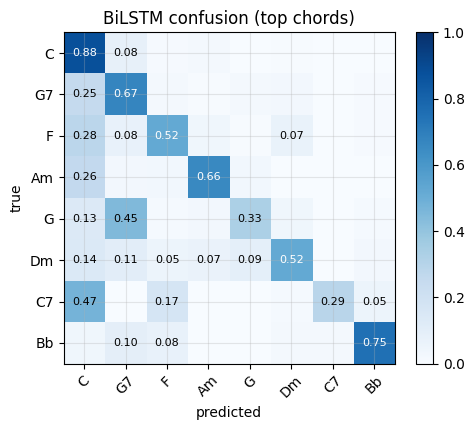

In [17]:
# confusion matrix over the most common chords (BiLSTM predictions)
from collections import defaultdict
labels = [c for c, _ in Counter(l for h in hte for _, l in h).most_common(8)]
idx = {l: i for i, l in enumerate(labels)}
M = np.zeros((len(labels), len(labels)))
for h in hte:
    pcvs = [p for p, _ in h]; gold = [l for _, l in h]
    for pred, g in zip(bilstm_predict(pcvs), gold):
        if g in idx and pred in idx:
            M[idx[g], idx[pred]] += 1
Mn = M / M.sum(1, keepdims=True).clip(min=1)
plt.figure(figsize=(5.2, 4.4))
plt.imshow(Mn, cmap="Blues", vmin=0, vmax=1)
plt.xticks(range(len(labels)), labels, rotation=45); plt.yticks(range(len(labels)), labels)
plt.xlabel("predicted"); plt.ylabel("true"); plt.title("BiLSTM confusion (top chords)")
for i in range(len(labels)):
    for j in range(len(labels)):
        if Mn[i, j] > .04:
            plt.text(j, i, f"{Mn[i,j]:.2f}", ha="center", va="center",
                     color="white" if Mn[i, j] > .5 else "black", fontsize=8)
plt.colorbar(fraction=.046); plt.tight_layout(); plt.show()

In [18]:
# ---- end-to-end demo: harmonise the melody we GENERATED in Task 1 ----
gen_bs = 16  # assume 4/4 for the generated melody
gen_pcvs = melody_bar_pcvs(gen_melody, gen_bs)
gen_chords = harmonizer_predict(harmonizer, gen_pcvs, citos, device, exclude_special=True)
harmonization_to_midi(gen_melody, gen_chords, gen_bs, "symbolic_conditioned.mid")
print("wrote symbolic_conditioned.mid (Task-1 melody harmonised by Task-2 model)")
print("predicted chords:", " ".join(c for c in gen_chords if c not in (PAD, UNK))[:120], "...")

pm = pretty_midi.PrettyMIDI("symbolic_conditioned.mid")
display(Audio(pm.synthesize(fs=16000), rate=16000))

wrote symbolic_conditioned.mid (Task-1 melody harmonised by Task-2 model)
predicted chords: C G7 C G F Am C G F C G7 C G7 G7 C G7 C G7 C C C G7 G7 C C ...


In [19]:
# ---- qualitative check vs ground truth on a held-out tune ----
demo = next(records[i] for i in test_idx if records[i]["melody"] and records[i]["bars"])
gold = [l for _, l in demo["bars"]]
pred = bilstm_predict([p for p, _ in demo["bars"]])
comp = pd.DataFrame({"bar": range(1, len(gold) + 1), "true chord": gold,
                     "BiLSTM chord": pred})
comp["match"] = comp["true chord"] == comp["BiLSTM chord"]
print(f"held-out tune: {demo['name']}  ({comp['match'].mean():.0%} bars exact)")
display(comp.head(16))

held-out tune: reelsa-c60.mid  (78% bars exact)


,bar,true chord,BiLSTM chord,match
0,1,F,F,True
1,2,F,F,True
2,3,F,F,True
3,4,C7,C7,True
4,5,F,F,True
5,6,F,F,True
6,7,C7,C,False
7,8,F,C7,False
8,9,F,F,True
9,10,F,F,True


**Findings (Task 2).** The BiLSTM roughly **doubles** the trivial majority baseline's chord
accuracy and beats it decisively on root accuracy. Strikingly, the **rule-based template baseline
is *worse* than always guessing the tonic**: matching instantaneous pitch content with no key or
progression context mis-fires on passing notes and ambiguous bars. This is the headline lesson of
the task &mdash; *harmonization is contextual*, and the BiLSTM's bidirectional view of the melody is
what lets it learn cadential patterns (the confusion matrix shows its main "errors" are sensible
substitutions like C&harr;Am or G&harr;G7). Accuracy still understates quality because multiple
chords can fit a bar, which is why we also listen to the output.

---
## 4. Related work
**The dataset.** The Nottingham corpus was popularised as a symbolic-music benchmark by
Boulanger-Lewandowski, Bengio & Vincent (ICML 2012), who modelled polyphonic piano-rolls with
RNN-RBM / RNN-NADE models and reported log-likelihood on exactly this data. It has since been a
standard testbed for melodic RNNs and for ABC-notation language models (e.g. *folk-rnn*,
Sturm et al. 2016, which trains LSTMs on transcribed folk tunes much like our Task 1).

**Unconditioned melody generation (Task 1).** Our approach mirrors Google Magenta's
*Melody RNN*: a step-tokenised monophonic stream modelled by an LSTM, sampled with temperature.
Modern systems (Music Transformer, Huang et al. 2019) replace the LSTM with self-attention for
much longer context; we deliberately use the smaller LSTM because it trains in minutes on a
laptop and already beats the n-gram baseline, which is the comparison the assignment asks for.

**Harmonization (Task 2).** Melody&rarr;chord harmonization has a long history, from rule/HMM
systems to neural taggers. Closely related are *DeepBach* (Hadjeres et al. 2017) and Coconet
(Huang et al. 2017), which harmonise Bach chorales with deep models; our BiLSTM tagger is a
lightweight cousin operating on chord *labels* per bar rather than full four-part voicing.

**How our results compare.** Consistent with this literature, (i) a learned sequence model beats
n-gram/rule baselines, (ii) local statistics (scale, rhythm) are easy to match while long-range
form is the hard part, and (iii) *accuracy/perplexity correlate with but do not fully capture
musical quality* &mdash; the recurring theme across all of these works, and the reason we pair
intrinsic metrics with distributional checks and listening.

---
## 5. Listen
The two deliverables, rendered with a simple sine synth so they play directly in this HTML.

In [20]:
print("Task 1 — symbolic_unconditioned.mid (generated melody)")
display(Audio(pretty_midi.PrettyMIDI("symbolic_unconditioned.mid").synthesize(fs=16000), rate=16000))
print("Task 2 — symbolic_conditioned.mid (that melody, harmonised)")
display(Audio(pretty_midi.PrettyMIDI("symbolic_conditioned.mid").synthesize(fs=16000), rate=16000))

Task 1 — symbolic_unconditioned.mid (generated melody)


Task 2 — symbolic_conditioned.mid (that melody, harmonised)
